# DAS next to seismological stations

The cable in these tutorials runs along the coast of the Coquimbo region, in
central Chile — one of the best-instrumented subduction margins in the
world. So for every earthquake the fiber records, there are permanent
seismometers that recorded it too.

Xdas reads both. This notebook puts a DAS acquisition and a regional network
into the same objects, and runs the *same* picking call on both.

In [1]:
import numpy as np

import xdas as xd

## Opening the stations

The waveforms were fetched from EarthScope once, by `install.py`, and written
as one miniSEED file per station in `data/stations/` — next to the
`stations.xml` inventory that says where those stations are. Nothing below
touches the network.

Nothing changes at the call site either: the same `xd.open`, the same
wildcard as for a directory of HDF5 files. The format is recognized from the
file, and miniSEED is decoded through ObsPy, as are SAC, GSE2 and everything
else it handles. Each contiguous trace becomes one lazy `DataArray`, and the
collection mirrors the `Stream` — nested network, station, location, channel.

In [2]:
dc = xd.open("data/stations/*.mseed")
dc

<xdas.DataCollection: 21 leaves, 1.4 MB>
network  station  location  channel  record
C1       CO01     --        HHE           0  (time: 18001)  70.3 KB
                            HHN           0  (time: 18001)  70.3 KB
                            HHZ           0  (time: 18001)  70.3 KB
         CO02     --        HHE           0  (time: 18001)  70.3 KB
                            HHN           0  (time: 18001)  70.3 KB
                            HHZ           0  (time: 18001)  70.3 KB
         CO03     --        HHE           0  (time: 18001)  70.3 KB
                            HHN           0  (time: 18001)  70.3 KB
                            HHZ           0  (time: 18001)  70.3 KB
         CO04     --        HHE           0  (time: 18000)  70.3 KB
                            HHN           0  (time: 18000)  70.3 KB
                            HHZ           0  (time: 18000)  70.3 KB
         CO05     --        HHE           0  (time: 18001)  70.3 KB
                            HHN

`stack` collapses a level of that tree into an array dimension. Here the
three channels of each station become one `(channel, time)` array:

In [3]:
dc = xd.stack(dc, "channel", join="inner")
dc

<xdas.DataCollection: 7 leaves, 1.4 MB>
network  station  location  record
C1       CO01     --             0  (channel: 3, time: 18001)  210.9 KB
         CO02     --             0  (channel: 3, time: 18001)  210.9 KB
         CO03     --             0  (channel: 3, time: 18001)  210.9 KB
         CO04     --             0  (channel: 3, time: 18000)  210.9 KB
         CO05     --             0  (channel: 3, time: 18001)  210.9 KB
         VA03     --             0  (channel: 3, time: 18001)  210.9 KB
         VA06     --             0  (channel: 3, time: 18000)  210.9 KB

```{note}
`join="inner"` is doing real work: the components of a station often differ
by a sample in length, and the inner join trims them to what they share.
```

One station, drawn:

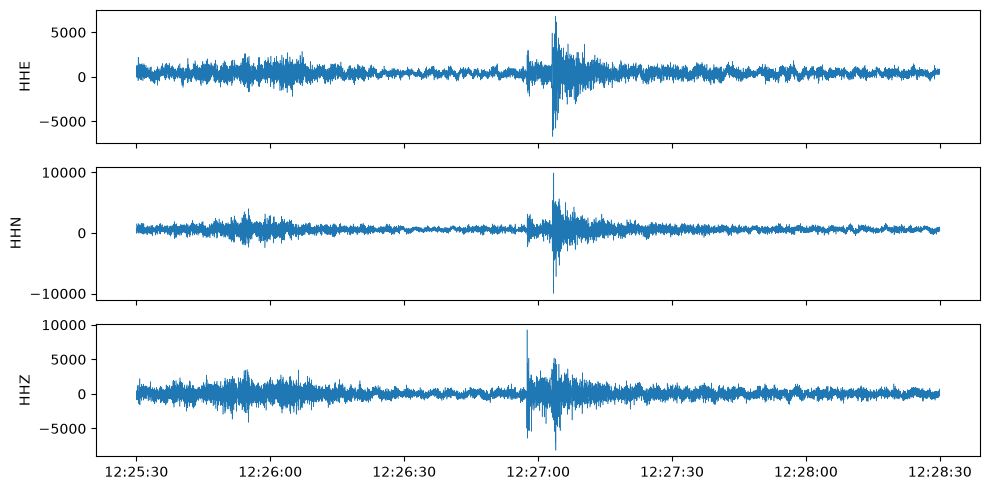

In [4]:
import matplotlib.pyplot as plt

station = dc["C1"]["CO05"]["--"][0]
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 5))
for ax, component in zip(axes, station["channel"].values):
    trace = station.sel(channel=component)
    ax.plot(trace["time"].values, trace.values, lw=0.4)
    ax.set_ylabel(str(component))
plt.tight_layout()
plt.show()

## The same picker, on a different instrument

This is the point of the notebook. The call below is character for character
the one used on the DAS acquisition — the same model, the same thresholds:

In [5]:
from seisbench.models import PhaseNet

model = PhaseNet.from_pretrained("diting")
picks = xd.pick(dc, model, thresh={"P": 0.3, "S": 0.3}, device="cpu")
picks

,network,station,location,record,phase,time,value
0,C1,CO01,--,0,P,2023-11-03 12:27:14.060000,0.686250
1,C1,CO01,--,0,S,2023-11-03 12:27:30.800000,0.797566
2,C1,CO02,--,0,P,2023-11-03 12:27:14.500000,0.715443
3,C1,CO02,--,0,S,2023-11-03 12:27:33.480000,0.478424
4,C1,CO03,--,0,P,2023-11-03 12:27:11.680000,0.908617
5,C1,CO03,--,0,S,2023-11-03 12:27:27.860000,0.557833
6,C1,CO04,--,0,P,2023-11-03 12:27:27.109998,0.523133
7,C1,CO04,--,0,S,2023-11-03 12:27:53.529998,0.330136
8,C1,CO05,--,0,P,2023-11-03 12:26:57.400000,0.967286
9,C1,CO05,--,0,S,2023-11-03 12:27:03.020000,0.887413


The pick table comes back flat, with each row labelled by where in the tree
it came from — network, station, location — so it merges directly with a
DAS pick table.

## Reading the picks back onto the waveforms

A pick table is only worth as much as the arrival underneath it. Drawing the
vertical component of every picked station, ordered by first arrival, checks
each row against the trace it came from — and the bandpass is the same
`xd.filter` notebook 02 ran on the fiber:

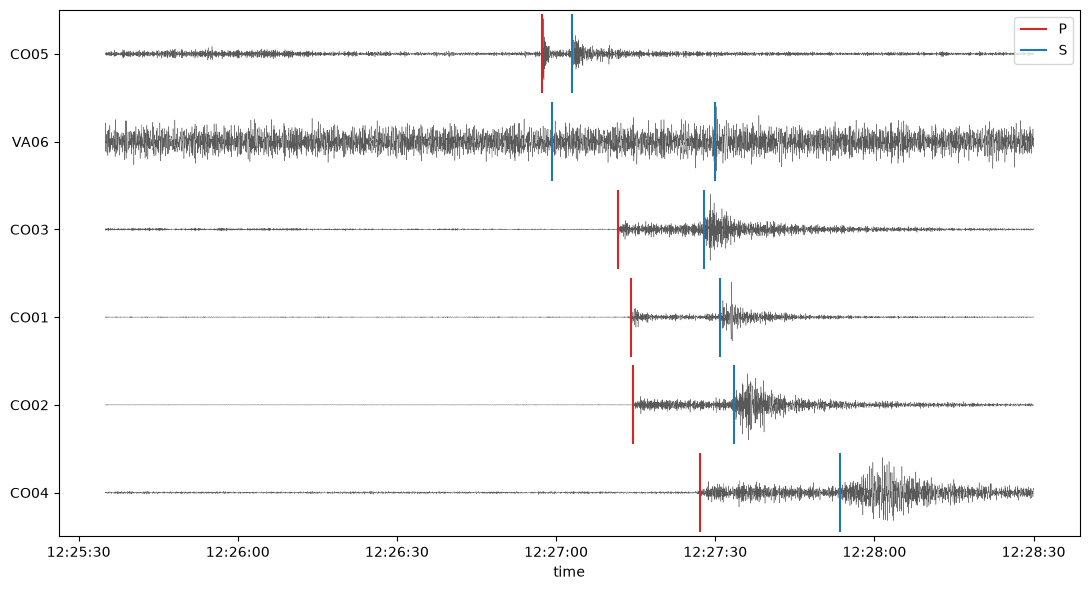

In [6]:
order = picks.groupby("station")["time"].min().sort_values().index

fig, ax = plt.subplots(figsize=(11, 6))
for offset, station in enumerate(order):
    trace = dc["C1"][station]["--"][0].sel(channel="HHZ")
    trace = xd.filter(trace, (2.0, 10.0), dim="time")  # bandpass 2-10 Hz
    trace = trace.isel(time=slice(500, None))  # drop the filter transient
    values = trace.values / np.max(np.abs(trace.values))
    ax.plot(trace["time"].values, offset + 0.4 * values, lw=0.3, c="0.35")
    for phase, colour in [("P", "C3"), ("S", "C0")]:
        rows = picks[(picks["station"] == station) & (picks["phase"] == phase)]
        ax.vlines(rows["time"], offset - 0.45, offset + 0.45, color=colour, lw=1.5)
        ax.vlines([], 0, 0, color=colour, label=phase if offset == 0 else None)

ax.set_yticks(range(len(order)), order)
ax.set_ylim(len(order) - 0.5, -0.5)  # earliest arrival on top
ax.set_xlabel("time")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

It is tempting to read that figure as two earthquakes — one at `CO05` just
before 12:27, another a few tens of seconds later on everything else. It is
one. What separates them is distance: this is ordinary travel-time moveout
across a network 250 km across, and the next notebook checks it arrival by
arrival.

The ordering is the interesting part, and the fiber belongs at the top of it.
The DAS picks from notebook 03 start at 12:26:54, ahead of every land
station including `CO05`, because the cable is the closest instrument to the
source — and it contributes not one arrival but hundreds.

The figure also shows what the table alone would not. `VA03` produced no
picks at all and is absent; `VA06` is noisy enough that its two arrivals were
both labelled `S`, with nothing visible under either of them. That leaves
four stations carrying almost all the information here, which is thin for
locating anything. That is the problem the next notebook runs into.

The table goes to disk as it is. Notebook 06 reads it back next to the
station inventory, and associates these arrivals into an event:

In [7]:
picks.to_csv("outputs/station_picks.csv", index=False)